In [28]:
from testflows.combinatorics import Covering
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn import svm
import random
from sklearn.neighbors import KNeighborsClassifier
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score


In [29]:
import opfython.math.general as g
import opfython.stream.parser as p
import opfython.stream.splitter as s
from opfython.models import SupervisedOPF
from opfython.stream import loader
from opfython.utils import logging

Load data set

In [30]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'..\\data\\data_temp\\cacao.csv')
df_algarrobo = pd.read_csv(r'..\\data\\data_temp\\algarrobo.csv')

df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]
X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())

C:\Users\salvador.romomacias\AppData\Local\Temp\ipykernel_13808\3369564250.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])


In [31]:
def ICAFS(dataset_X, dataset_Y, strenght,max_iteartion,model, print_logs=False):

  max_it = 1 
  score_list = []
  featur_list = []
  iter_list = []
  
  v_variable = [0, 1]
  best_f1_score = float('-inf')
  max_iteartion_aux =  max_iteartion
  best_data_set = dataset_X.columns.values.copy()

  initial_test_training(score_list,iter_list,featur_list,dataset_X,dataset_Y,model)
  while max_iteartion_aux >= 0:

      dict_parameters = {}
      partial_best_list = []
      partial_score = 0
      for colum_key in best_data_set:
          dict_parameters[colum_key] = v_variable
      random.shuffle(best_data_set)
      generate_covering_array = Covering(dict_parameters, strength=strenght)
      for test in generate_covering_array.array:
          list_attributes_to_consider = []

          check_for_all_cero = True
          for (test_key, test_value) in test.items():
              if test_value == 1:
                  check_for_all_cero = False
                  list_attributes_to_consider.append(test_key)

          if check_for_all_cero:
              continue  
          df_temp = dataset_X.loc[ :,list_attributes_to_consider]
          X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(df_temp.values, dataset_Y.values.ravel(), test_size=0.20,
                                                                                  random_state=42)
          clf_new = train_model(model)
          clf_new.fit(X_train_temp, y_train_temp)

          y_pred = clf_new.predict(X_test_temp)
          #if print_logs:
          #  print(f"atributes to consider={', '.join(list_attributes_to_consider)}")
          score = f1_score(y_test_temp, y_pred,average='macro')
          if score > partial_score :
              partial_score = score
              partial_best_list = list_attributes_to_consider
          clf_new = None
      best_data_set = partial_best_list.copy()
      best_f1_score = partial_score
      
      if print_logs:
        print(f"best f1 score= {best_f1_score}, iteration:{max_it}, numbers features selected ={ len(best_data_set)},best features selected={', '.join(best_data_set)}" )

      aux_data_score = best_f1_score
      score_list.append(aux_data_score)
      max_iteartion_aux = max_iteartion_aux-1
      max_it = max_it +1
      featur_list.append(len(best_data_set))
      iter_list.append(max_it)
  return iter_list,featur_list,score_list

def initial_test_training(score_list, iter_list, feature_list ,X,y,model):
     X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X.values, y.values.ravel(), test_size=0.20, random_state=42)
     clf_new = train_model(model)
     clf_new.fit(X_train_temp, y_train_temp)
     y_pred = clf_new.predict(X_test_temp)
     score_list.append(f1_score(y_test_temp, y_pred,average='macro'))
     feature_list.append(X.shape[1])
     iter_list.append(0)

def train_model(model_name='ComplementNB'):  
    m = eval(model_name)
    return m

In [32]:
def  plot_results_for_covering_array(scores,feature,num_of_iterarion, path_to_save_image):
        color = 'tab:blue'
        res_scores = np.array(scores)
        res_features = np.array(feature)
        res_iter = np.array(num_of_iterarion)

        plt.figure(figsize=(11, 10))
        
        fig, ax1 = plt.subplots()
        barwidth = 0.4
        color = 'tab:red'
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Number of features', color=color)
        #ax1.set_title("ICAFS Feature selection on the Cacao dataset")
        ax1.spines['top'].set_visible(False)
        ax1.bar(res_iter-0.2, res_features, color=color, width=barwidth)
        ax1.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax1.set_ylim(1,max(res_features)+3)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        for bar in ax1.patches:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height}', fontsize=10,
                    ha='center', va='bottom', rotation=90)
            
        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('F1_score', color=color)
        ax2.bar(res_iter+0.2, res_scores, color=color, width=barwidth)
        ax2.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax2.set_ylim(min(res_scores)-0.001, max(res_scores)+0.001)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
       
        for bar in ax2.patches:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height:.2f}', fontsize=10,
                    ha='center', va='bottom', rotation=90)

        #plt.title('ICAFS Feature selection for Cacao Dataset with OPF', y=-0.20)
        plt.gca().set_frame_on(False)
        plt.savefig(path_to_save_image)

ICAFS KNN

best f1 score= 0.902081289227973, iteration:1, numbers features selected =799,best features selected=1103, 1696, 1697, 1698, 1699, 1700, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1708, 1709, 1710, 1711, 1712, 1713, 1714, 1715, 1716, 1717, 1718, 1720, 1721, 1722, 1723, 1724, 1725, 1726, 1728, 1729, 1730, 1731, 1732, 1733, 1734, 1735, 1736, 1737, 1738, 1739, 1740, 1741, 1742, 1743, 1744, 1745, 1746, 1747, 1748, 1749, 1750, 1752, 1753, 1754, 1755, 1756, 1757, 1758, 1759, 1760, 1761, 1762, 1763, 1764, 1765, 1766, 1767, 1768, 1769, 1770, 1771, 1772, 1773, 1774, 1775, 1776, 1777, 1778, 1779, 1780, 1781, 1782, 1783, 1784, 1785, 1786, 1787, 1788, 1789, 1790, 1791, 1792, 1793, 1794, 1795, 1796, 1797, 1798, 1799, 1800, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1848, 1849,

<Figure size 1100x1000 with 0 Axes>

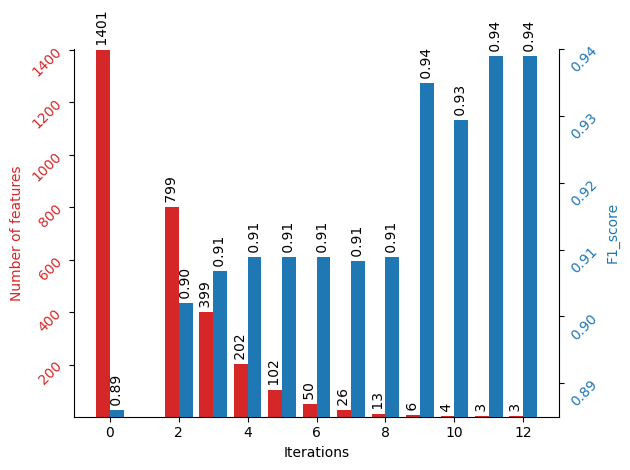

In [33]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cacao,y_cacao,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/cacao_knn_icafs.png')

5 Fold Validation ICAFS KNN

In [34]:
clf = KNeighborsClassifier(n_neighbors=3)
X = X_cacao[['1736', '1993', '2089']]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Cacao nibs mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )


5-CV Cacao nibs mean:0.897521551813014 , 5-CV Cacao STD:0.06379850690808213


best f1 score= 0.8193496587715776, iteration:1, numbers features selected =13,best features selected=G, Edge Red, NIR, EXG, NGRDI, NGBDI, GBRI.1, CIVE, MGRVI, NDVI, EVI, REVI, REDVI
best f1 score= 0.8044083352140223, iteration:2, numbers features selected =5,best features selected=NGRDI, NGBDI, GBRI.1, NDVI, EVI
best f1 score= 0.7699079631852741, iteration:3, numbers features selected =4,best features selected=NGRDI, NGBDI, GBRI.1, EVI
best f1 score= 0.7198879551820728, iteration:4, numbers features selected =3,best features selected=NGRDI, NGBDI, GBRI.1
best f1 score= 0.7198879551820728, iteration:5, numbers features selected =3,best features selected=NGRDI, NGBDI, GBRI.1
best f1 score= 0.7198879551820728, iteration:6, numbers features selected =3,best features selected=NGRDI, NGBDI, GBRI.1
best f1 score= 0.7198879551820728, iteration:7, numbers features selected =3,best features selected=NGRDI, NGBDI, GBRI.1
best f1 score= 0.7198879551820728, iteration:8, numbers features selected =3

<Figure size 1100x1000 with 0 Axes>

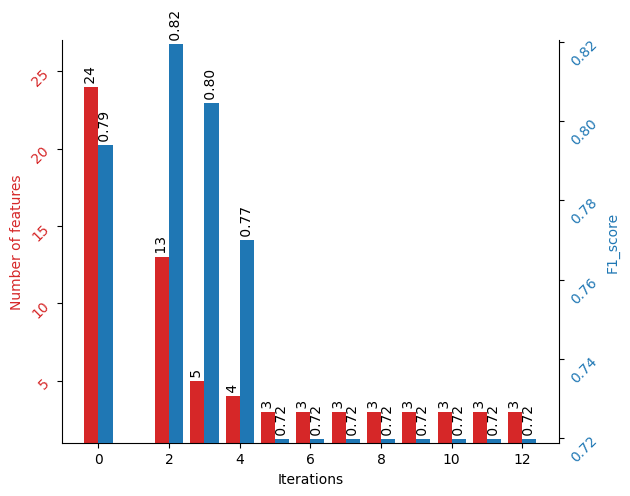

In [35]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_knn_icafs.png')

5 Cross Validation KNN Algarrobo

In [36]:
clf = KNeighborsClassifier(n_neighbors=3)
X = X_algarrobo[['NGRDI', 'NGBDI', 'GBRI.1', 'NDVI', 'EVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV algarrobo mean:{res.mean()} , 5-CV algarrobo STD:{res.std()}" )

5-CV algarrobo mean:0.6979561046789613 , 5-CV algarrobo STD:0.0707038091614825


best f1 score= 0.9809972636059592, iteration:1, numbers features selected =3,best features selected=X, Y, X10
best f1 score= 0.9914973960775487, iteration:2, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9914973960775487, iteration:3, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9914973960775487, iteration:4, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9914973960775487, iteration:5, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9914973960775487, iteration:6, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9914973960775487, iteration:7, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9914973960775487, iteration:8, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9914973960775487, iteration:9, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9914973960775487, iteration:10, n

<Figure size 1100x1000 with 0 Axes>

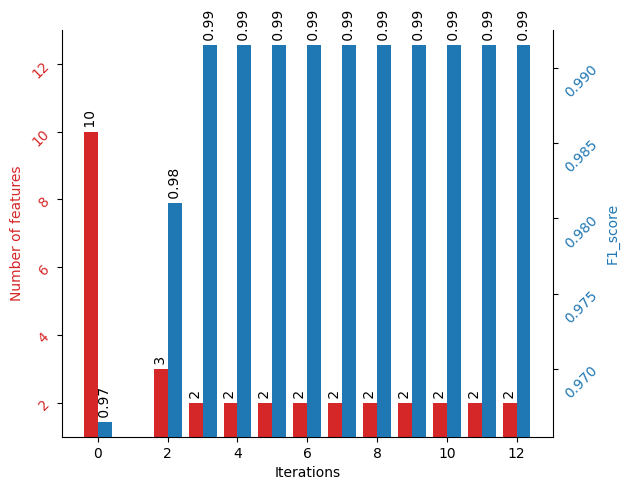

In [37]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'KNeighborsClassifier(n_neighbors=3)',True)
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')

5 Cross Validation CIS

In [38]:
clf = KNeighborsClassifier(n_neighbors=3)
X = X_cis[['X', 'Y']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )

5-CV CIS mean:0.9862988696637448 , 5-CV CIS STD:0.0009278667797298965


ICAFS OPF

2025-03-08 18:28:53,017 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-08 18:28:53,018 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-08 18:28:53,019 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-08 18:28:53,020 - opfython.core.opf — INFO — Class created.
2025-03-08 18:28:53,020 - opfython.models.supervised — INFO — Class overrided.
2025-03-08 18:28:53,021 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-08 18:28:53,024 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-08 18:28:53,317 - opfython.models.supervised — DEBUG — Prototypes: [638, 406, 206, 164, 596, 464, 188, 265, 504, 521, 195, 729, 320, 149, 395, 28, 261, 38, 256, 266, 632, 69, 359, 517, 51, 170, 644, 444, 426, 383, 696, 686, 693, 567, 424, 319, 397, 507, 85, 510, 654, 461, 791, 668, 289, 416, 605, 641, 457, 664, 280, 427, 283, 617, 220, 4, 75, 328, 749, 59, 401, 734, 493, 481, 3

<Figure size 1100x1000 with 0 Axes>

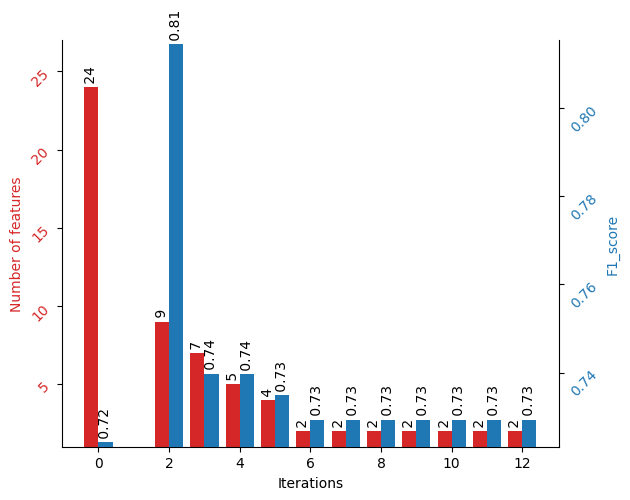

In [39]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_opf_icafs.png')

2025-03-08 18:30:05,018 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-08 18:30:05,019 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-08 18:30:05,020 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-08 18:30:05,021 - opfython.core.opf — INFO — Class created.
2025-03-08 18:30:05,021 - opfython.models.supervised — INFO — Class overrided.


2025-03-08 18:30:05,022 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-08 18:30:05,025 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-08 18:30:05,770 - opfython.models.supervised — DEBUG — Prototypes: [225, 287, 653, 313, 761, 740, 366, 262, 145, 25, 285, 752, 178, 578, 515, 182, 695, 549, 123, 563, 341, 647, 325, 597, 167, 632, 37, 408, 711, 63, 45, 656, 658, 121, 163, 521, 421, 388, 109, 363, 713, 791, 483, 668, 395, 208, 156, 72, 558, 725, 398, 719, 619, 65, 299, 750, 70, 250, 426, 256, 43, 3, 624, 358, 193, 270, 599, 626, 679, 572, 405, 120, 762, 657, 705, 253, 783, 261, 90, 75, 251, 244, 326, 516, 126, 131, 491, 707, 602, 779, 663, 523, 141, 165, 414, 374, 757, 526, 776, 127, 722, 48, 356, 323, 188, 331, 385, 294, 782, 355, 737, 670, 404, 24, 272, 410, 80, 540, 241, 786, 368, 784, 57, 511, 771, 181, 17, 754, 290, 764, 170, 322, 455, 559, 644, 306, 464, 770, 185, 86, 396, 721, 654, 566, 315, 284, 309, 399, 144, 142, 473, 731, 362, 633, 6

<Figure size 1100x1000 with 0 Axes>

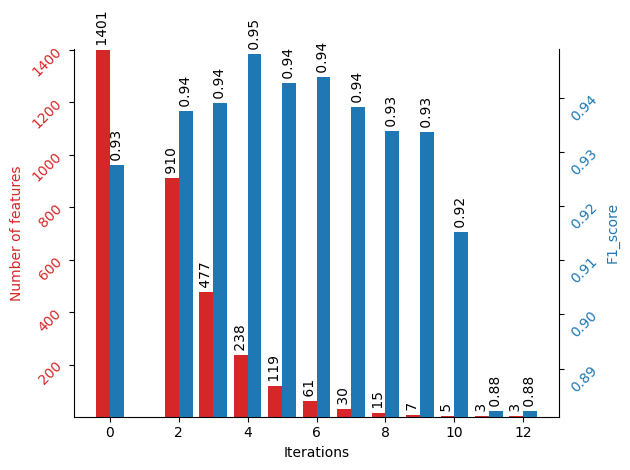

In [40]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_opf_icafs.png')

2025-03-08 18:36:47,829 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-08 18:36:47,829 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-08 18:36:47,829 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-08 18:36:47,829 - opfython.core.opf — INFO — Class created.
2025-03-08 18:36:47,839 - opfython.models.supervised — INFO — Class overrided.
2025-03-08 18:36:47,840 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-08 18:36:47,865 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-08 18:37:13,281 - opfython.models.supervised — DEBUG — Prototypes: [199, 447, 4439, 743, 3024, 925, 5082, 3317, 3435, 7027, 1606, 1084, 5634, 3235, 1628, 5012, 7937, 422, 4560, 5781, 4329, 3637, 6881, 5426, 4785, 2674, 6732, 3847, 2064, 806, 5611, 2261, 4038, 3258, 4900, 4060, 6505, 3880, 4187, 2566, 136, 994, 3487, 7479, 6929, 794, 168, 297, 1966, 3035, 3663, 3675, 5829, 1927,

<Figure size 1100x1000 with 0 Axes>

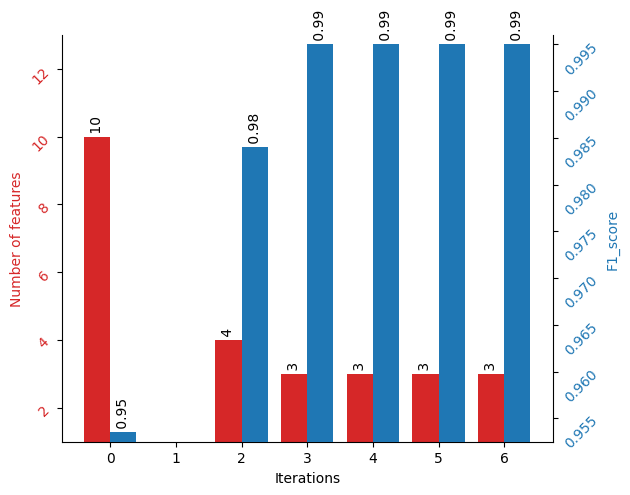

In [41]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,4,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/cis_opf_icafs.png')

ICAFS SVC

best f1 score= 0.711397908020655, iteration:1, numbers features selected =718,best features selected=1107, 1116, 1117, 1118, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1128, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1164, 1167, 1171, 1184, 1185, 1186, 1187, 1191, 1192, 1193, 1194, 1197, 1198, 1200, 1201, 1202, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1220, 1221, 1222, 1223, 1227, 1228, 1231, 1235, 1248, 1249, 1250, 1251, 1256, 1257, 1258, 1261, 1262, 1264, 1265, 1266, 1268, 1269, 1270, 1271, 1272, 1273, 1274, 1275, 1276, 1277, 1278, 1279, 1284, 1285, 1286, 1287, 1291, 1292, 1295, 1299, 1312, 1313, 1314, 1315, 1320, 1321, 1322, 1325, 1326, 1328, 1329, 1330, 1332, 1333, 1334, 1335, 1336, 1337, 1338, 1339, 1340, 1341, 1342, 1343, 1348, 1349, 1350, 1351, 1355, 1356, 1359, 1363, 1376,

<Figure size 1100x1000 with 0 Axes>

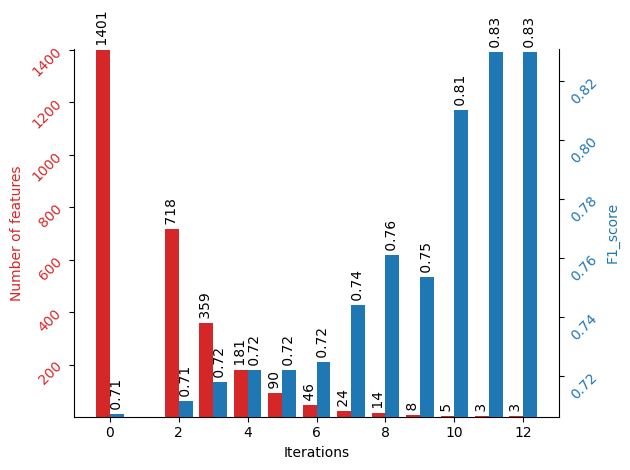

In [42]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'svm.SVC()' ,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_svc_icafs.png')

5 Cross SVC ICAFS Cacao

In [43]:
clf = svm.SVC()
X = X_cacao[['1734', '1926', '2310']]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Cacao mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

5-CV Cacao mean:0.8230015663113133 , 5-CV Cacao STD:0.07054212671304273


best f1 score= 0.7749493636068115, iteration:1, numbers features selected =13,best features selected=G, Edge Red, NIR, EXG, NGRDI, NGBDI, GBRI.1, CIVE, MGRVI, NDVI, EVI, REVI, REDVI
best f1 score= 0.7849946248656217, iteration:2, numbers features selected =5,best features selected=NIR, CIVE, NDVI, EVI, REDVI
best f1 score= 0.77, iteration:3, numbers features selected =4,best features selected=NIR, CIVE, NDVI, REDVI
best f1 score= 0.77, iteration:4, numbers features selected =3,best features selected=NIR, CIVE, NDVI
best f1 score= 0.77, iteration:5, numbers features selected =3,best features selected=NIR, CIVE, NDVI
best f1 score= 0.77, iteration:6, numbers features selected =3,best features selected=NIR, CIVE, NDVI
best f1 score= 0.77, iteration:7, numbers features selected =3,best features selected=NIR, CIVE, NDVI
best f1 score= 0.77, iteration:8, numbers features selected =3,best features selected=NIR, CIVE, NDVI
best f1 score= 0.77, iteration:9, numbers features selected =3,best fea

<Figure size 1100x1000 with 0 Axes>

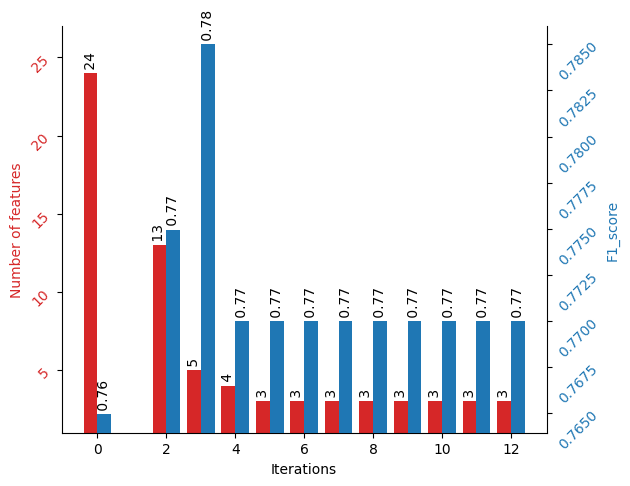

In [44]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'svm.SVC()',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_svc_icafs.png')

ICAFS KNN SVC Algarrobo

In [45]:
clf = svm.SVC()
X = X_algarrobo[['NIR', 'CIVE', 'NDVI', 'EVI', 'REDVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Algarrobo mean:{res.mean()} , 5-CV ALgarrobo STD:{res.std()}" )

5-CV Algarrobo mean:0.7482284534699325 , 5-CV ALgarrobo STD:0.03362987294329091


best f1 score= 0.9804999561249013, iteration:1, numbers features selected =4,best features selected=X, Y, X40, Y40
best f1 score= 0.9834996658682338, iteration:2, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9834996658682338, iteration:3, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9834996658682338, iteration:4, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9834996658682338, iteration:5, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9834996658682338, iteration:6, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9834996658682338, iteration:7, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9834996658682338, iteration:8, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9834996658682338, iteration:9, numbers features selected =3,best features selected=X, Y, Y40
best 

<Figure size 1100x1000 with 0 Axes>

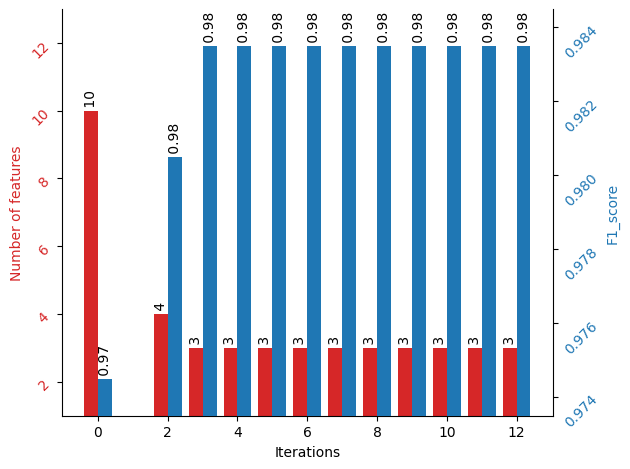

In [46]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')

5 Cross Validation ICAFS CIS SVC

In [47]:
clf = svm.SVC()
X = X_cis[['X', 'Y', 'Y40']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )

5-CV CIS mean:0.9776880241490421 , 5-CV CIS STD:0.0036194375244417236


ICAFS MLP

best f1 score= 0.9891919191919193, iteration:1, numbers features selected =1399,best features selected=1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1128, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1247, 1248, 1249, 1250, 125

c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


best f1 score= 0.9841629134231695, iteration:6, numbers features selected =171,best features selected=1217, 1219, 1221, 1226, 1232, 1234, 1236, 1238, 1248, 1250, 1252, 1254, 1264, 1266, 1268, 1270, 1280, 1282, 1284, 1286, 1296, 1298, 1300, 1302, 1312, 1314, 1316, 1318, 1328, 1330, 1332, 1334, 1344, 1346, 1348, 1350, 1360, 1362, 1364, 1366, 1376, 1378, 1380, 1382, 1392, 1394, 1396, 1398, 1408, 1410, 1412, 1414, 1424, 1426, 1428, 1430, 1443, 1445, 1447, 1449, 1459, 1461, 1463, 1465, 1478, 1480, 1482, 1484, 1495, 1497, 1499, 1501, 1511, 1514, 1516, 1518, 1528, 1530, 1532, 1534, 1544, 1546, 1548, 1551, 1562, 1564, 1567, 1569, 1579, 1581, 1583, 1585, 1595, 1597, 1600, 1602, 1613, 1617, 1625, 1634, 1677, 1681, 1690, 1692, 1723, 1725, 1737, 1743, 1755, 1757, 1773, 1776, 1787, 1798, 1806, 1808, 1820, 1822, 1837, 1839, 1852, 1865, 1872, 1875, 1888, 1894, 1896, 1898, 1911, 1913, 1915, 1918, 1932, 1935, 1938, 1940, 1953, 1959, 1962, 1967, 1977, 1979, 1984, 1991, 2021, 2023, 2025, 2027, 2078, 2080

c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


best f1 score= 0.9841629134231695, iteration:7, numbers features selected =169,best features selected=1221, 1226, 1232, 1234, 1236, 1238, 1248, 1250, 1252, 1254, 1264, 1266, 1268, 1270, 1280, 1282, 1284, 1286, 1296, 1298, 1300, 1302, 1312, 1314, 1316, 1318, 1328, 1330, 1332, 1334, 1344, 1346, 1348, 1350, 1360, 1362, 1364, 1366, 1376, 1378, 1380, 1382, 1392, 1394, 1396, 1398, 1408, 1410, 1412, 1414, 1424, 1426, 1428, 1430, 1443, 1445, 1447, 1449, 1459, 1461, 1463, 1465, 1478, 1480, 1482, 1484, 1495, 1497, 1499, 1501, 1511, 1514, 1516, 1518, 1528, 1530, 1532, 1534, 1544, 1546, 1548, 1551, 1562, 1564, 1567, 1569, 1579, 1581, 1583, 1585, 1595, 1597, 1600, 1602, 1613, 1617, 1625, 1634, 1677, 1681, 1690, 1692, 1723, 1725, 1737, 1743, 1755, 1757, 1773, 1776, 1787, 1798, 1806, 1808, 1820, 1822, 1837, 1839, 1852, 1865, 1872, 1875, 1888, 1894, 1896, 1898, 1911, 1913, 1915, 1918, 1932, 1935, 1938, 1940, 1953, 1959, 1962, 1967, 1977, 1979, 1984, 1991, 2021, 2023, 2025, 2027, 2078, 2080, 2082, 2084

...

c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Ma

best f1 score= 0.9643183825536766, iteration:10, numbers features selected =82,best features selected=1248, 1252, 1264, 1268, 1280, 1284, 1296, 1300, 1312, 1316, 1328, 1332, 1344, 1348, 1360, 1364, 1376, 1380, 1392, 1396, 1408, 1412, 1424, 1428, 1443, 1447, 1459, 1463, 1478, 1482, 1495, 1499, 1511, 1516, 1528, 1532, 1544, 1548, 1562, 1567, 1579, 1583, 1595, 1600, 1613, 1625, 1677, 1690, 1723, 1737, 1755, 1773, 1787, 1806, 1820, 1837, 1852, 1872, 1888, 1896, 1911, 1915, 1932, 1938, 1953, 1962, 1977, 1984, 2021, 2025, 2078, 2082, 2120, 2124, 2217, 2236, 2264, 2297, 2401, 2424, 2489, 2499


c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Ma

best f1 score= 0.9596384933311676, iteration:11, numbers features selected =80,best features selected=1264, 1268, 1280, 1284, 1296, 1300, 1312, 1316, 1328, 1332, 1344, 1348, 1360, 1364, 1376, 1380, 1392, 1396, 1408, 1412, 1424, 1428, 1443, 1447, 1459, 1463, 1478, 1482, 1495, 1499, 1511, 1516, 1528, 1532, 1544, 1548, 1562, 1567, 1579, 1583, 1595, 1600, 1613, 1625, 1677, 1690, 1723, 1737, 1755, 1773, 1787, 1806, 1820, 1837, 1852, 1872, 1888, 1896, 1911, 1915, 1932, 1938, 1953, 1962, 1977, 1984, 2021, 2025, 2078, 2082, 2120, 2124, 2217, 2236, 2264, 2297, 2401, 2424, 2489, 2499
Processing time: 5192.441765069962 seconds


<Figure size 1100x1000 with 0 Axes>

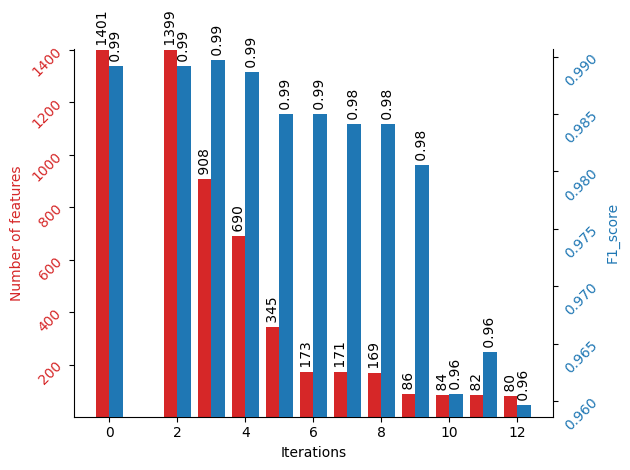

In [48]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_mlp_icafs.png')

ICAFS MLP CACAO 5 CV

In [49]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_cacao[['1235', '1255', '1257', '1259', '1260', '1271', '1272', '1275', '1279', '1290', '1318', '1319', '1321', '1325', '1328', '1329', '1330', '1341', '1346', '1347', '1349', '1350', '1353', '1371', '1373', '1375', '1376', '1431', '1454', '1455', '1460', '1478', '1484', '1489', '1490', '1502', '1513', '1515', '1529', '1531', '1571', '1573', '1597', '1598', '1631', '1675', '1679', '1696', '1712', '1714', '1733', '1742', '1748', '1756', '1757', '1767', '1825', '1827', '1829', '1830', '1883', '1912', '1931', '1943', '1967', '1969', '1974', '1997', '2004', '2012', '2013', '2023', '2082', '2084', '2086', '2093', '2142', '2172', '2198', '2213', '2229', '2238', '2245', '2267', '2279', '2284', '2296', '2323', '2394', '2396', '2398', '2399']
]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Cacao mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


5-CV Cacao mean:0.9444590176468279 , 5-CV Cacao STD:0.042231979248493645


c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


best f1 score= 0.7649941248531213, iteration:1, numbers features selected =13,best features selected=R, G, B, NIR, EXGR, NGBDI, GBRI, CIVE, RGBVI, NDVI, DVI, REVI, RERVI
best f1 score= 0.7699769976997699, iteration:2, numbers features selected =5,best features selected=G, NDVI, DVI, REVI, RERVI
best f1 score= 0.7699769976997699, iteration:3, numbers features selected =4,best features selected=G, NDVI, DVI, RERVI
best f1 score= 0.7649941248531213, iteration:4, numbers features selected =3,best features selected=G, NDVI, DVI
best f1 score= 0.7699769976997699, iteration:5, numbers features selected =3,best features selected=G, NDVI, DVI
best f1 score= 0.7649941248531213, iteration:6, numbers features selected =3,best features selected=G, NDVI, DVI
best f1 score= 0.7649941248531213, iteration:7, numbers features selected =3,best features selected=G, NDVI, DVI
best f1 score= 0.7649941248531213, iteration:8, numbers features selected =3,best features selected=G, NDVI, DVI
best f1 score= 0.77

<Figure size 1100x1000 with 0 Axes>

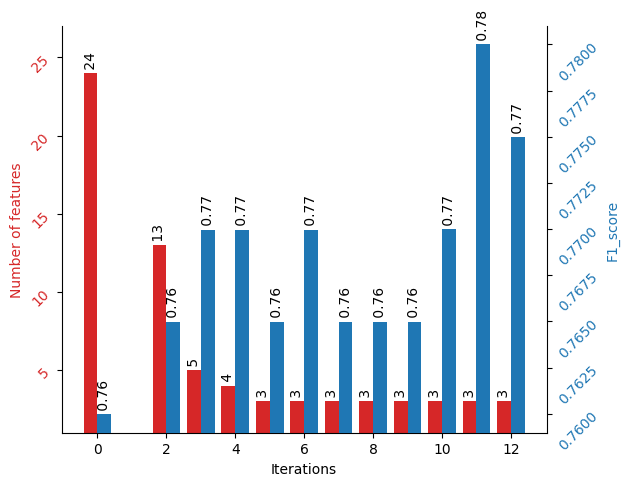

In [50]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)' ,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_mlp_icafs.png')

ICAFS MLP Algarrobo 5 CV

In [51]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_algarrobo[['R', 'MGRVI', 'REDVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Algarrobo mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )

5-CV Algarrobo mean:0.7302595329021655 , 5-CV Algarrobo STD:0.050331684434644246


best f1 score= 0.9589996309966791, iteration:1, numbers features selected =4,best features selected=X, Y, X40, Y40
best f1 score= 0.9594982888027019, iteration:2, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.95999983999936, iteration:3, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.959499908874795, iteration:4, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9584987445870238, iteration:5, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9594997468734179, iteration:6, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.95999963999676, iteration:7, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.95999983999936, iteration:8, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.960999960999961, iteration:9, numbers features selected =3,best features selected=X, Y, Y40
best f1 score

<Figure size 1100x1000 with 0 Axes>

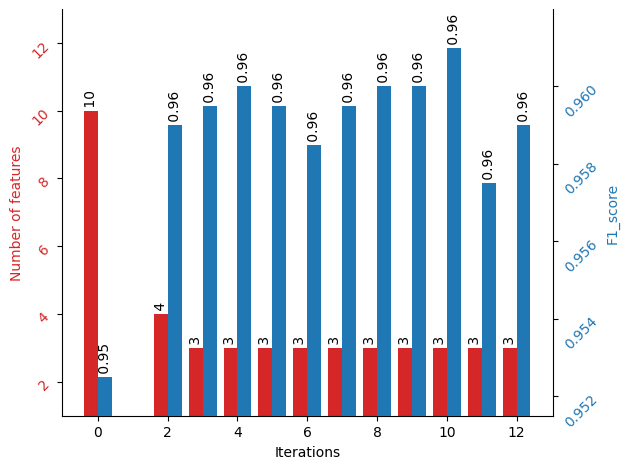

In [52]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_mlp_icafs.png')

ICAFS MLP CIS 5 CV

In [53]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_cis[['X', 'Y', 'Y40']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )

5-CV CIS mean:0.9573728021762967 , 5-CV CIS STD:0.0036163099579014056
